In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.svm import SVR

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [7]:
data = pd.read_csv("/content/drive/MyDrive/Dataset/CarPrice_Assignment.csv")

In [8]:
print(data.head())
print(data.shape)
print(data.columns)
print(data.info())
print(data.describe())
print(data.isnull().sum())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [10]:

data = data.dropna()

In [9]:
print(data.duplicated().sum())

0


In [11]:
if 'car_ID' in data.columns:

    data.drop('car_ID', axis=1, inplace=True)

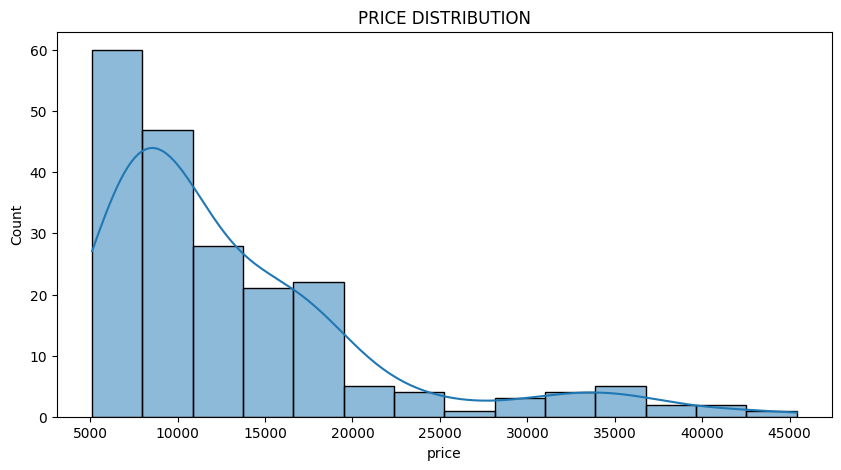

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(data['price'], kde=True)

plt.title("PRICE DISTRIBUTION")

plt.show()

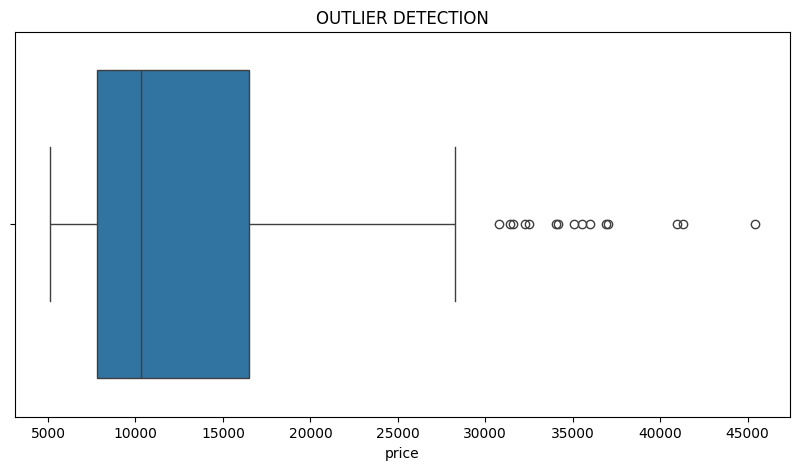

In [13]:
plt.figure(figsize=(10,5))

sns.boxplot(x=data['price'])

plt.title("OUTLIER DETECTION")

plt.show()

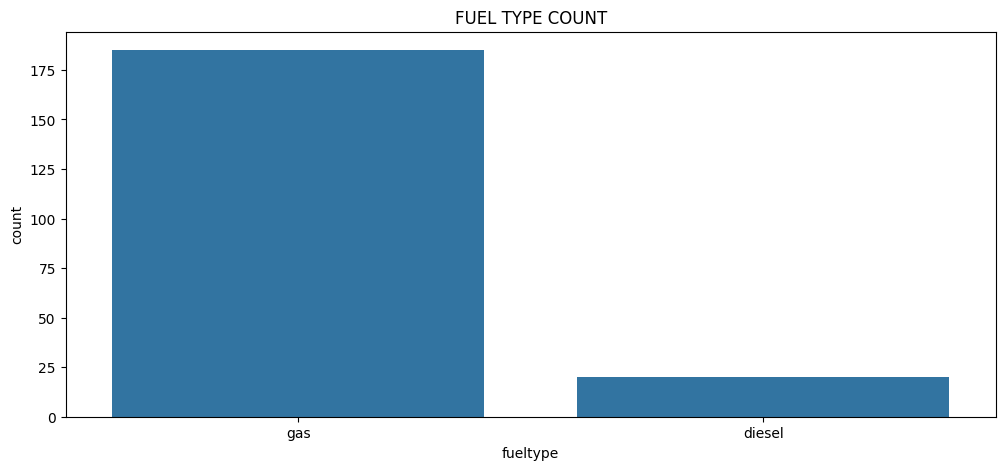

In [14]:
plt.figure(figsize=(12,5))

sns.countplot(x=data['fueltype'])

plt.title("FUEL TYPE COUNT")

plt.show()

In [15]:
le = LabelEncoder()

for col in data.columns:

    if data[col].dtype == 'object':

        data[col] = le.fit_transform(data[col])

In [16]:
Q1 = data['price'].quantile(0.25)

Q3 = data['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

data = data[

    (data['price'] >= lower) &

    (data['price'] <= upper)
]


In [17]:
X = data.drop('price', axis=1)

y = data['price']


In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,

    y,

    test_size=0.2,

    random_state=42
)

In [20]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [21]:
dt = DecisionTreeRegressor(

    max_depth=10,

    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [36]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [31]:
svm = SVR(
    kernel='rbf',
    C=100,
    gamma=0.1
)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [24]:

knn = KNeighborsRegressor(

    n_neighbors=5
)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [37]:
def evaluate_model(name, y_test, y_pred):

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    print("\n---------------------------------")

    print("MODEL :", name)

    print("-----------------------------------")

    print("MAE :", mae)

    print("MSE :", mse)

    print("RMSE :", rmse)

    print("R2 SCORE :", r2)

In [38]:
evaluate_model(

    "Linear Regression",

    y_test,

    y_pred_lr
)

evaluate_model(

    "Decision Tree",

    y_test,

    y_pred_dt
)

evaluate_model(

    "Random Forest",

    y_test,

    y_pred_rf
)

evaluate_model(

    "Support Vector Machine",

    y_test,

    y_pred_svm
)

evaluate_model(

    "KNN",

    y_test,

    y_pred_knn
)


---------------------------------
MODEL : Linear Regression
-----------------------------------
MAE : 1425.8552222061703
MSE : 3232440.984176031
RMSE : 1797.8990472704609
R2 SCORE : 0.8077019455117778

---------------------------------
MODEL : Decision Tree
-----------------------------------
MAE : 1171.1337807017544
MSE : 3453411.8332383074
RMSE : 1858.3357697785154
R2 SCORE : 0.7945563801073972

---------------------------------
MODEL : Random Forest
-----------------------------------
MAE : 872.1589605263158
MSE : 1517100.5941343482
RMSE : 1231.706374967
R2 SCORE : 0.9097476197885399

---------------------------------
MODEL : Support Vector Machine
-----------------------------------
MAE : 3064.317960849165
MSE : 12683226.746959448
RMSE : 3561.3518145445064
R2 SCORE : 0.24547429016867528

---------------------------------
MODEL : KNN
-----------------------------------
MAE : 1242.6149210526319
MSE : 2712595.234586553
RMSE : 1646.9958210592258
R2 SCORE : 0.838627591724468


In [39]:
models = [

    'Linear Regression',

    'Decision Tree',

    'Random Forest',

    'SVM',

    'KNN'
]

scores = [

    r2_score(y_test, y_pred_lr),

    r2_score(y_test, y_pred_dt),

    r2_score(y_test, y_pred_rf),

    r2_score(y_test, y_pred_svm),

    r2_score(y_test, y_pred_knn)
]

comparison = pd.DataFrame({

    'Model': models,

    'R2 Score': scores
})

print("\nMODEL COMPARISON")

print(comparison)


MODEL COMPARISON
               Model  R2 Score
0  Linear Regression  0.807702
1      Decision Tree  0.794556
2      Random Forest  0.909748
3                SVM  0.245474
4                KNN  0.838628


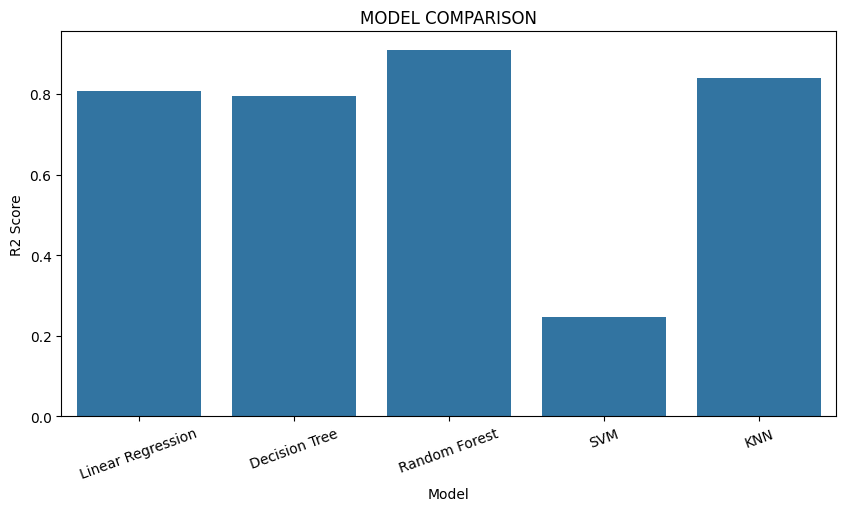

In [40]:
plt.figure(figsize=(10,5))

sns.barplot(

    x='Model',

    y='R2 Score',

    data=comparison
)

plt.title("MODEL COMPARISON")

plt.xticks(rotation=20)

plt.show()

In [41]:
best_model = comparison.loc[

    comparison['R2 Score'].idxmax()
]

print("\nBEST MODEL")

print(best_model)


BEST MODEL
Model       Random Forest
R2 Score         0.909748
Name: 2, dtype: object
